In [1]:
import sys, pathlib
repo_root = pathlib.Path("/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline


In [13]:
# Load plans and pick one sample
from thesis_package import config, io
import resplan_utils as R

plans = io.load_data(config.PKL_PATH)
plan_idx = 0  # change this to inspect another plan
raw_plan = R.normalize_keys(plans[plan_idx].copy())
plan_idx


0

In [14]:
# Extract room and structural instances
from thesis_package.plan_utils import extract_room_instances, split_walls

rooms = extract_room_instances(raw_plan)
structural = split_walls(raw_plan)

room_counts = {k: len(v) for k, v in rooms.items()}
struct_counts = {k: len(v) for k, v in structural.items()}
room_counts, struct_counts


SKIPPED: interior_wall fragment with area 0.00m²


({'bedroom': 2,
  'bathroom': 2,
  'kitchen': 1,
  'living': 1,
  'balcony': 2,
  'storage': 1,
  'stair': 0,
  'veranda': 0,
  'parking': 0},
 {'interior_wall': 10,
  'exterior_wall': 28,
  'door': 7,
  'window': 4,
  'front_door': 1})

In [15]:
# Build relations/graph bundle
from thesis_package.graph import export_graph

graph_bundle = export_graph(raw_plan, rooms, structural)
relations_summary = {k: len(v) for k, v in graph_bundle['relations'].items()}
relations_summary


{'bounded_by': 2,
 'adjacent_to': 1,
 'hosts_opening': 24,
 'connected_via_door': 8}

JSON saved to: /Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/resplan_json/plan_00000.json


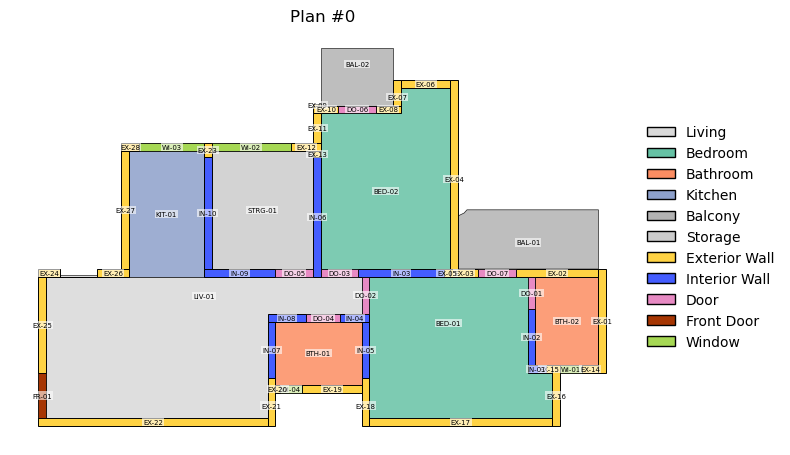

In [31]:
# Assemble artefact and persist JSON/plot outputs
from thesis_package import config
from thesis_package.visualize import plot_plan_json

# Ekspor main artefact (JSON + plot tanpa label)
json_path = config.export_one(plan_idx, raw_plan)
print(f"JSON saved to: {json_path}")

# Bangun nama file untuk plot berlabel dan simpan tampilannya
label_path = config.PLOT_LABEL_DIR / f"plan_{plan_idx:05d}_ids.png"

ax = plot_plan_json(json_path, show_ids=True, figsize=(8, 7))
ax.figure.savefig(label_path, dpi=200, bbox_inches="tight")




In [32]:
import json, random
from pathlib import Path
from thesis_package.synthetic import load_plan, save_plan, generate_variants

plan_path_imp = Path("/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_json") #location to save imperfect plans
plan_path_imp.mkdir(parents=True, exist_ok=True)  # ensure directory exists

# pick a plan from the output folder
plan_path = Path("/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/resplan_json/plan_00000.json")
plan = load_plan(plan_path)  # or: plan = json.loads(plan_path.read_text())

# optional: fix the random seed so you can reproduce the same drops
rng = random.Random(42)

# build the four imperfect variants
variants = generate_variants(plan, rng=rng)

# save each variant back to disk
for name, imperfect in variants.items():
    out_path = plan_path_imp / f"{plan_path.stem}_{name}.json"
    save_plan(imperfect, out_path)
    print(f"Saved {name} → {out_path}")



Saved drop_interior_wall → /Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_json/plan_00000_drop_interior_wall.json
Saved drop_door → /Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_json/plan_00000_drop_door.json
Saved drop_window → /Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_json/plan_00000_drop_window.json
Saved drop_all_structural → /Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_json/plan_00000_drop_all_structural.json


Rendering plan_00000_drop_all_structural.json


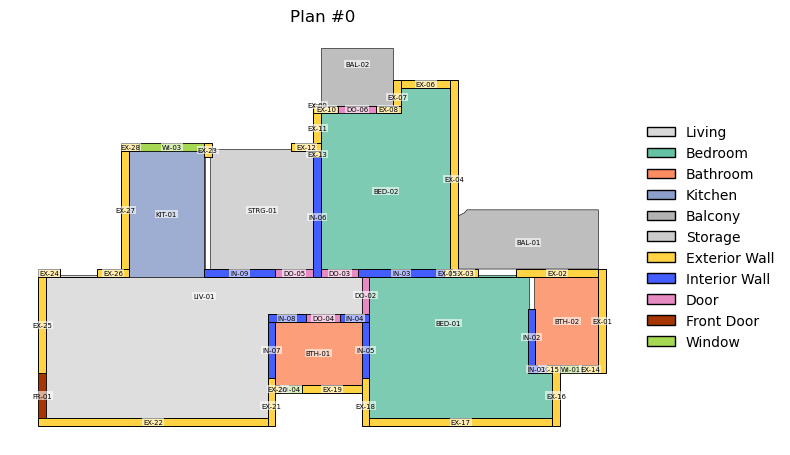

Rendering plan_00000_drop_door.json


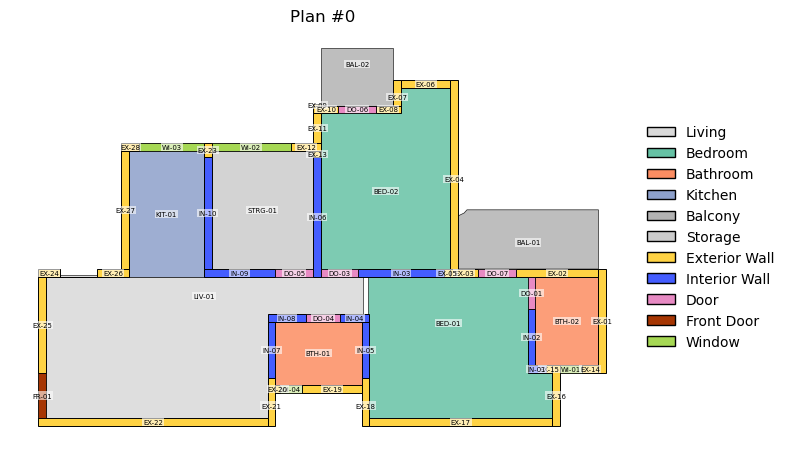

Rendering plan_00000_drop_interior_wall.json


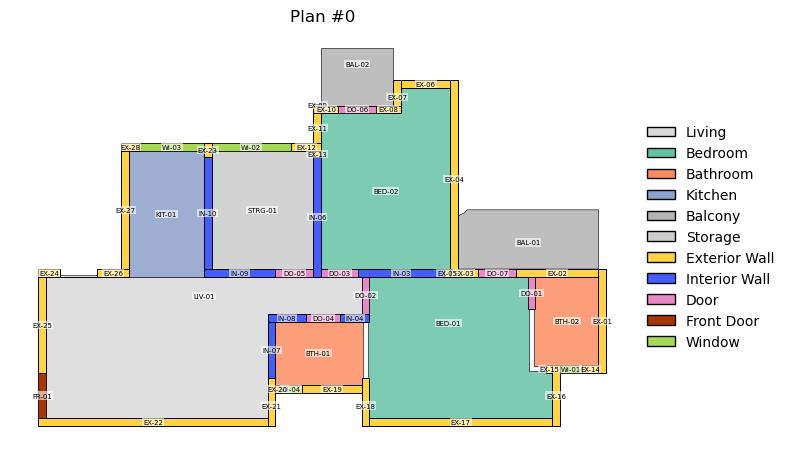

Rendering plan_00000_drop_window.json


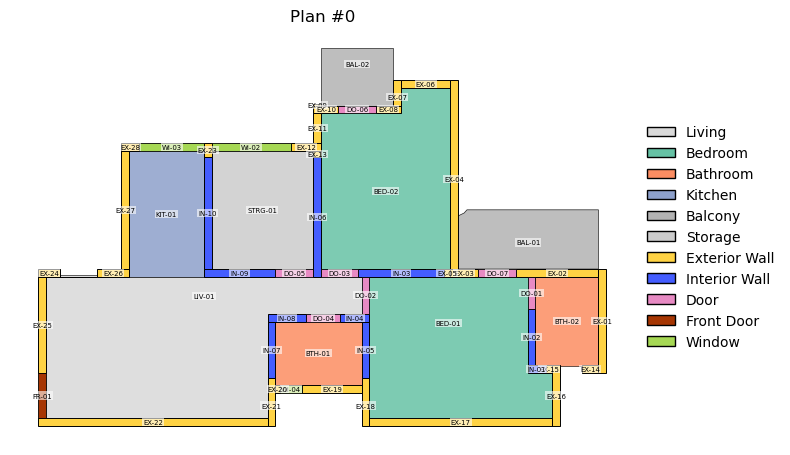

In [33]:
from pathlib import Path
from thesis_package.visualize import plot_plan_json
import matplotlib.pyplot as plt

# folder containing the imperfect plans
variant_dir = Path("/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_json")

# list all JSON files you want to inspect
json_paths = sorted(variant_dir.glob("plan_00000_drop_*.json"))

for json_path in json_paths:
    print(f"Rendering {json_path.name}")
    ax = plot_plan_json(json_path, show_ids=True, figsize=(8, 7))
    plt.show()        # display inline
    plt.close(ax.figure)

In [34]:
# Convert JSON plan to TTL
from pathlib import Path
import sys

repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from ontology.json_to_ttl import convert

for json_path in Path('/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_json').glob("plan_00000_drop_*.json"):
    ttl_path = Path('/Users/muhammadnumanmuttaqi/Documents/MScITBE/Thesis/Thesis/Geometry-to-Ontology/output/imp_resplan_ttl') / f"{json_path.stem}.ttl"
    convert(json_path, ttl_path)
    print(f"Converted {json_path.name} to {ttl_path.name}")




Skipping hosts_opening edge with unknown ids: {'id': 'E-host-00015', 'wall': 'EX-14', 'opening': 'WI-01', 'opening_type': 'window'}
Skipping hosts_opening edge with unknown ids: {'id': 'E-host-00016', 'wall': 'EX-16', 'opening': 'WI-01', 'opening_type': 'window'}
Window WI-01 referenced in windows_on_exterior but not found.
Window WI-01 referenced in windows_on_exterior but not found.
Skipping hosts_opening edge with unknown ids: {'id': 'E-host-00017', 'wall': 'EX-12', 'opening': 'WI-02', 'opening_type': 'window'}
Skipping hosts_opening edge with unknown ids: {'id': 'E-host-00018', 'wall': 'EX-23', 'opening': 'WI-02', 'opening_type': 'window'}
Door DO-01 not found for connected_via_door entry E-pass-00001.
Door DO-07 not found for connected_via_door entry E-pass-00007.
Window WI-02 referenced in windows_on_exterior but not found.
Window WI-02 referenced in windows_on_exterior but not found.
Window WI-02 referenced in windows_on_exterior but not found.
Window WI-02 referenced in windows

Converted plan_00000_drop_window.json to plan_00000_drop_window.ttl
Converted plan_00000_drop_all_structural.json to plan_00000_drop_all_structural.ttl
Converted plan_00000_drop_interior_wall.json to plan_00000_drop_interior_wall.ttl
Converted plan_00000_drop_door.json to plan_00000_drop_door.ttl


In [ ]:
# [ARCHIVED] #DOOR RULES MISSING CHECKER
# from pyshacl import validate
# from rdflib import Graph

# data_graph = Graph().parse("../output/imp_resplan_ttl/plan_00000_drop_door.ttl", format="turtle")
# shacl_graph = Graph().parse("../ontology/rules/DoorRule.shacl.ttl", format="turtle")
# onto_graph = Graph().parse("../ontology/core/Resplan.ttl", format="turtle")

# conforms, report_graph, _ = validate(
#     data_graph,
#     shacl_graph=shacl_graph,
#     ont_graph=onto_graph,
#     inference="rdfs",
#     meta_shacl=True,
#     advanced=True,
# )

# print(report_graph.serialize(format="turtle"))


@prefix resplan: <http://resplan.org/resplan#> .
@prefix sh: <http://www.w3.org/ns/shacl#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

[] a sh:ValidationReport ;
    sh:conforms false ;
    sh:result [ a sh:ValidationResult ;
            sh:focusNode <http://resplan.org/resplan/plan_00000#BED-01> ;
            sh:resultSeverity sh:Violation ;
            sh:sourceConstraint [ sh:select """
        PREFIX resplan: <http://resplan.org/resplan#>
        PREFIX bot: <https://w3id.org/bot#>
        SELECT DISTINCT ?this ?other ?msg WHERE {
            ?this resplan:connectedViaDoor ?other .
            FILTER (?this != ?other)
            FILTER (STR(?this) < STR(?other))
            FILTER NOT EXISTS {
                ?wall resplan:hostsOpening ?door .
                ?door a resplan:Door .
                ?door resplan:connectsSpace ?this .
                ?door resplan:connectsSpace ?other .
            }
            
        }
        """ ] ;
            sh:sourceConstraintCom

In [ ]:
# [ARCHIVED] #DOOR RULES MISSING CHECKER
# from pyshacl import validate
# from rdflib import RDF, Graph, Namespace

# def _short(node):
#     node = str(node)
#     return node.split('#')[-1] if '#' in node else node

# data_graph = Graph().parse("../output/imp_resplan_ttl/plan_00000_drop_door.ttl", format="turtle")
# shacl_graph = Graph().parse("../ontology/rules/DoorRule.shacl.ttl", format="turtle")
# onto_graph = Graph().parse("../ontology/core/Resplan.ttl", format="turtle")

# conforms, report_graph, _ = validate(
#     data_graph,
#     shacl_graph=shacl_graph,
#     ont_graph=onto_graph,
#     inference="rdfs",
#     meta_shacl=True,
#     advanced=True,
# )

# sh = Namespace("http://www.w3.org/ns/shacl#")

# if not conforms:
#     for result in report_graph.subjects(RDF.type, sh.ValidationResult):
#         focus = report_graph.value(result, sh.focusNode)
#         message = report_graph.value(result, sh.resultMessage)
#         shape = report_graph.value(result, sh.sourceShape)
#         print(f"- {_short(focus)} violates {_short(shape)}: {message}")


- BED-01 violates DW3_MissingDoor: Door must connect exactly two spaces via connected_via_door relationships.


In [ ]:
# [ARCHIVED] #DOOR RULES MISSING CHECKER
# from pyshacl import validate
# from rdflib import RDF, Graph, Namespace, Literal

# def _short(node):
#     node = str(node)
#     return node.split('#')[-1] if '#' in node else node

# data_graph = Graph().parse("../output/imp_resplan_ttl/plan_00000_drop_door.ttl", format="turtle")
# shacl_graph = Graph().parse("../ontology/rules/DoorRule.shacl.ttl", format="turtle")
# onto_graph = Graph().parse("../ontology/core/Resplan.ttl", format="turtle")

# conforms, report_graph, _ = validate(
#     data_graph,
#     shacl_graph=shacl_graph,
#     ont_graph=onto_graph,
#     inference="rdfs",
#     meta_shacl=True,
#     advanced=True,
# )

# sh = Namespace("http://www.w3.org/ns/shacl#")

# print('Conforms:', conforms)

# if not conforms:
#     for result in report_graph.subjects(RDF.type, sh.ValidationResult):

#         focus = report_graph.value(result, sh.focusNode)
#         shape = report_graph.value(result, sh.sourceShape)
#         comp  = report_graph.value(result, sh.sourceConstraintComponent)

#         # Jika ini SPARQLConstraintComponent → ambil query dari sourceConstraint
#         if comp == sh.SPARQLConstraintComponent:
#             sparql_text = None

#             # Ambil sh:select dalam sourceConstraint
#             for sc in report_graph.objects(result, sh.sourceConstraint):
#                 sparql_text = report_graph.value(sc, sh.select)
#                 if isinstance(sparql_text, Literal):
#                     sparql_text = str(sparql_text)

#             if sparql_text:
#                 # Jalankan query ulang ke data_graph
#                 violations = list(data_graph.query(sparql_text))

#                 if len(violations) > 0:
#                     for row in violations:
#                         # Biasanya row terdiri dari (?this, ?other, ?msg?) sesuai query
#                         vals = list(row)
#                         if len(vals) >= 2:
#                             id1 = _short(vals[0])
#                             id2 = _short(vals[1])
#                             print(f"{id1} – {id2}: Door is missing between these two spaces.")
#                         else:
#                             print(f"{_short(focus)} violates {_short(shape)} (SPARQL rule)")
#                 else:
#                     print(f"{_short(focus)} violates {_short(shape)} but no pair found in SPARQL binding")

#         else:
#             # fallback: violation biasa
#             msg = report_graph.value(result, sh.resultMessage)
#             print(f"- {_short(focus)} violates {_short(shape)}: {msg}")


Conforms: False
BED-01 – LIV-01: Door is missing between these two spaces.


In [35]:
# DOOR RULES MISSING CHECKER
from pyshacl import validate
from rdflib import RDF, Graph, Namespace, RDFS, BNode, Literal

def _short(node):
    return str(node).split("#")[-1] if "#" in str(node) else str(node)

data_graph = Graph().parse("../output/imp_resplan_ttl/plan_00000_drop_all_structural.ttl", format="turtle")
shacl_graph = Graph().parse("../ontology/rules/DoorRule.shacl.ttl", format="turtle")
onto_graph = Graph().parse("../ontology/core/Resplan.ttl", format="turtle")

conforms, report_graph, _ = validate(
    data_graph,
    shacl_graph=shacl_graph,
    ont_graph=onto_graph,
    inference="rdfs",
    meta_shacl=True,
    advanced=True,
)

sh = Namespace("http://www.w3.org/ns/shacl#")

if conforms:
    print("All door rules satisfied.")
else:
    print("Door rule violations found:")

    handled_sparql_rules = set()

    for result in report_graph.subjects(RDF.type, sh.ValidationResult):
        raw_shape = report_graph.value(result, sh.sourceShape)

        # mapped from PropertyShape/SPARQL bnode to main NodeShape (using shacl_graph!)
        rule_node = raw_shape
        if isinstance(raw_shape, BNode):
            for ns in shacl_graph.subjects(sh.property, raw_shape):
                rule_node = ns
                break

        rule_id = _short(rule_node)
        rule_label = report_graph.value(rule_node, RDFS.label) or shacl_graph.value(rule_node, RDFS.label)
        rule_name = str(rule_label) if rule_label else rule_id

        comp = report_graph.value(result, sh.sourceConstraintComponent)
        focus = _short(report_graph.value(result, sh.focusNode))
        message_node = report_graph.value(result, sh.resultMessage)
        message = str(message_node) if isinstance(message_node, Literal) or message_node else ""

        if comp == sh.SPARQLConstraintComponent:
            if rule_node in handled_sparql_rules:
                continue  # already processed this rule
            handled_sparql_rules.add(rule_node)
            
            sc = report_graph.value(result, sh.sourceConstraint)
            sparql = report_graph.value(sc, sh.select)

            for row in data_graph.query(str(sparql)):
                if len(row) >= 2:
                    print(f"{_short(row[0])} – {_short(row[1])}: {message} ({rule_name})")
                else:
                    print(f"{' – '.join(_short(v) for v in row)}: {message} ({rule_name})")
        else:
            print(f"- {focus} violates {rule_name}: {message}")


Door rule violations found:
BAL-01 – BED-01: Door must connect exactly two spaces via connected_via_door relationships. (DW2: Missing door between spaces declared as connectedViaDoor)
BED-01 – BTH-02: Door must connect exactly two spaces via connected_via_door relationships. (DW2: Missing door between spaces declared as connectedViaDoor)


In [ ]:
# # [ARCHIVED] WINDOW RULES MISSING CHECKER
# from pyshacl import validate
# from rdflib import RDF, Graph, Namespace

# def _short(node):
#     node = str(node)
#     return node.split('#')[-1] if '#' in node else node

# data_graph = Graph().parse('../output/imp_resplan_ttl/plan_00000_drop_window.ttl', format='turtle')
# shacl_graph = Graph().parse('../ontology/rules/WindowRule.shacl.ttl', format='turtle')
# onto_graph = Graph().parse('../ontology/core/Resplan.ttl', format='turtle')

# conforms, report_graph, _ = validate(
#     data_graph,
#     shacl_graph=shacl_graph,
#     ont_graph=onto_graph,
#     inference='rdfs',
#     meta_shacl=True,
#     advanced=True,
# )

# sh = Namespace('http://www.w3.org/ns/shacl#')

# if conforms:
#     print("All window rules satisfied.")
# else :
#     print("Window rule violations found:")
#     for result in report_graph.subjects(RDF.type, sh.ValidationResult):
#         focus = report_graph.value(result, sh.focusNode)
#         message = report_graph.value(result, sh.resultMessage)
#         shape = report_graph.value(result, sh.sourceShape)
#         print(f"- {_short(focus)} violates {_short(shape)}: {message}")



Window rule violations found:
- BTH-02 violates W2_BathroomNeedsWindow: Bathroom has no window hosted on its walls.
- BED-01 violates W1_MinOneWindow_Habitable: Habitable space (Living/Bedroom/Kitchen) has no window hosted on its walls.


In [36]:
# WINDOW RULES MISSING CHECKER
from pyshacl import validate
from rdflib import RDF, Graph, Namespace

def _short(node):
    node = str(node)
    return node.split('#')[-1] if '#' in node else node

data_graph = Graph().parse('../output/imp_resplan_ttl/plan_00000_drop_window.ttl', format='turtle')
shacl_graph = Graph().parse('../ontology/rules/WindowRule.shacl.ttl', format='turtle')
onto_graph = Graph().parse('../ontology/core/Resplan.ttl', format='turtle')

conforms, report_graph, _ = validate(
    data_graph,
    shacl_graph=shacl_graph,
    ont_graph=onto_graph,
    inference="rdfs",
    meta_shacl=True,
    advanced=True,
)

sh = Namespace("http://www.w3.org/ns/shacl#")

if conforms:
    print("All window rules satisfied.")
else:
    print("Window rule violations found:")

    handled_sparql_rules = set()

    for result in report_graph.subjects(RDF.type, sh.ValidationResult):
        raw_shape = report_graph.value(result, sh.sourceShape)

        # mapped from PropertyShape/SPARQL bnode to main NodeShape (using shacl_graph!)
        rule_node = raw_shape
        if isinstance(raw_shape, BNode):
            for ns in shacl_graph.subjects(sh.property, raw_shape):
                rule_node = ns
                break

        rule_id = _short(rule_node)
        rule_label = report_graph.value(rule_node, RDFS.label) or shacl_graph.value(rule_node, RDFS.label)
        rule_name = str(rule_label) if rule_label else rule_id

        comp = report_graph.value(result, sh.sourceConstraintComponent)
        focus = _short(report_graph.value(result, sh.focusNode))
        message_node = report_graph.value(result, sh.resultMessage)
        message = str(message_node) if isinstance(message_node, Literal) or message_node else ""

        if comp == sh.SPARQLConstraintComponent:
            if rule_node in handled_sparql_rules:
                continue  # already processed this rule
            handled_sparql_rules.add(rule_node)
            
            sc = report_graph.value(result, sh.sourceConstraint)
            sparql = report_graph.value(sc, sh.select)

            for row in data_graph.query(str(sparql)):
                if len(row) >= 2:
                    print(f"{_short(row[0])} – {_short(row[1])}: {message} ({rule_name})")
                else:
                    print(f"{' – '.join(_short(v) for v in row)}: {message} ({rule_name})")
        else:
            print(f"- {focus} violates {rule_name}: {message}")

Window rule violations found:
BTH-02: Room has window opening on exterior wall but window is not present. (W5: window is not present)
BED-01: Room has window opening on exterior wall but window is not present. (W5: window is not present)
BTH-02: Bathroom has no window recorded on its exterior walls. (W2: Bathrooms must have at least one window)
BTH-02: Window is missing in this room (W1: Expected window on this room)
BED-01: Window is missing in this room (W1: Expected window on this room)


In [4]:
#CONNECTIVITY RULES CHECKER (WALLS, DOOR, ROOMS CONNECTIVITY)
from pyshacl import validate
from rdflib import RDF, Graph, Namespace

def _short(node):
    node = str(node)
    return node.split('#')[-1] if '#' in node else node

data_graph = Graph().parse('../output/imp_resplan_ttl/plan_00000_drop_interior_wall.ttl', format='turtle')
shacl_graph = Graph().parse('../ontology/rules/ConnectivityRule.shacl.ttl', format='turtle')
onto_graph = Graph().parse('../ontology/core/Resplan.ttl', format='turtle')

conforms, report_graph, _ = validate(
    data_graph,
    shacl_graph=shacl_graph,
    ont_graph=onto_graph,
    inference='rdfs',
    meta_shacl=True,
    advanced=True,
)

sh = Namespace('http://www.w3.org/ns/shacl#')

if conforms:
    print("All connectivity rules satisfied.")
else :
    print("Connectivity rule violations found:")
    for result in report_graph.subjects(RDF.type, sh.ValidationResult):
        focus = report_graph.value(result, sh.focusNode)
        message = report_graph.value(result, sh.resultMessage)
        shape = report_graph.value(result, sh.sourceShape)
        print(f"- {_short(focus)} violates {_short(shape)}: {message}")

All connectivity rules satisfied.


In [22]:
# ADJACENCY RULES CHECKER
from pyshacl import validate
from rdflib import RDF, Graph, Namespace

def _short(node):
    node = str(node)
    return node.split('#')[-1] if '#' in node else node

data_graph = Graph().parse('../output/imp_resplan_ttl/plan_00000_drop_interior_wall.ttl', format='turtle')
shacl_graph = Graph().parse('../ontology/rules/AdjacencyRule.shacl.ttl', format='turtle')
onto_graph = Graph().parse('../ontology/core/Resplan.ttl', format='turtle')

conforms, report_graph, _ = validate(
    data_graph,
    shacl_graph=shacl_graph,
    ont_graph=onto_graph,
    inference="rdfs",
    meta_shacl=True,
    advanced=True,
)

sh = Namespace("http://www.w3.org/ns/shacl#")

if conforms:
    print("All adjacency rules satisfied.")
else:
    print("Adjacency rule violations found:")

    handled_sparql_rules = set()

    for result in report_graph.subjects(RDF.type, sh.ValidationResult):
        raw_shape = report_graph.value(result, sh.sourceShape)

        # mapped from PropertyShape/SPARQL bnode to main NodeShape (using shacl_graph!)
        rule_node = raw_shape
        if isinstance(raw_shape, BNode):
            for ns in shacl_graph.subjects(sh.property, raw_shape):
                rule_node = ns
                break

        rule_id = _short(rule_node)
        rule_label = report_graph.value(rule_node, RDFS.label) or shacl_graph.value(rule_node, RDFS.label)
        rule_name = str(rule_label) if rule_label else rule_id

        comp = report_graph.value(result, sh.sourceConstraintComponent)
        focus = _short(report_graph.value(result, sh.focusNode))
        message_node = report_graph.value(result, sh.resultMessage)
        message = str(message_node) if isinstance(message_node, Literal) or message_node else ""

        if comp == sh.SPARQLConstraintComponent:
            if rule_node in handled_sparql_rules:
                continue  # already processed this rule
            handled_sparql_rules.add(rule_node)
            
            sc = report_graph.value(result, sh.sourceConstraint)
            sparql = report_graph.value(sc, sh.select)

            for row in data_graph.query(str(sparql)):
                if len(row) >= 2:
                    print(f"{_short(row[0])} – {_short(row[1])}: {message} ({rule_name})")
                else:
                    print(f"{' – '.join(_short(v) for v in row)}: {message} ({rule_name})")
        else:
            print(f"- {focus} violates {rule_name}: {message}")

All adjacency rules satisfied.
